**Задание**

В файле movies.csv лежит база фильмов. Название фильма записано во втором столбце title.
Разбейте названия фильмов на отдельные слова и посчитайте какое слово встречается чаще всего.  
*Вместо title - Film.*

Если у вас не получится со Спарком, то сделайте задание просто на питоне.  
___________________________________________________________________  

**Выполнила задание**  


*   и со спарком. В качестве результата скрины из среды docker.desctop;
*   и на пайтон.






In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image

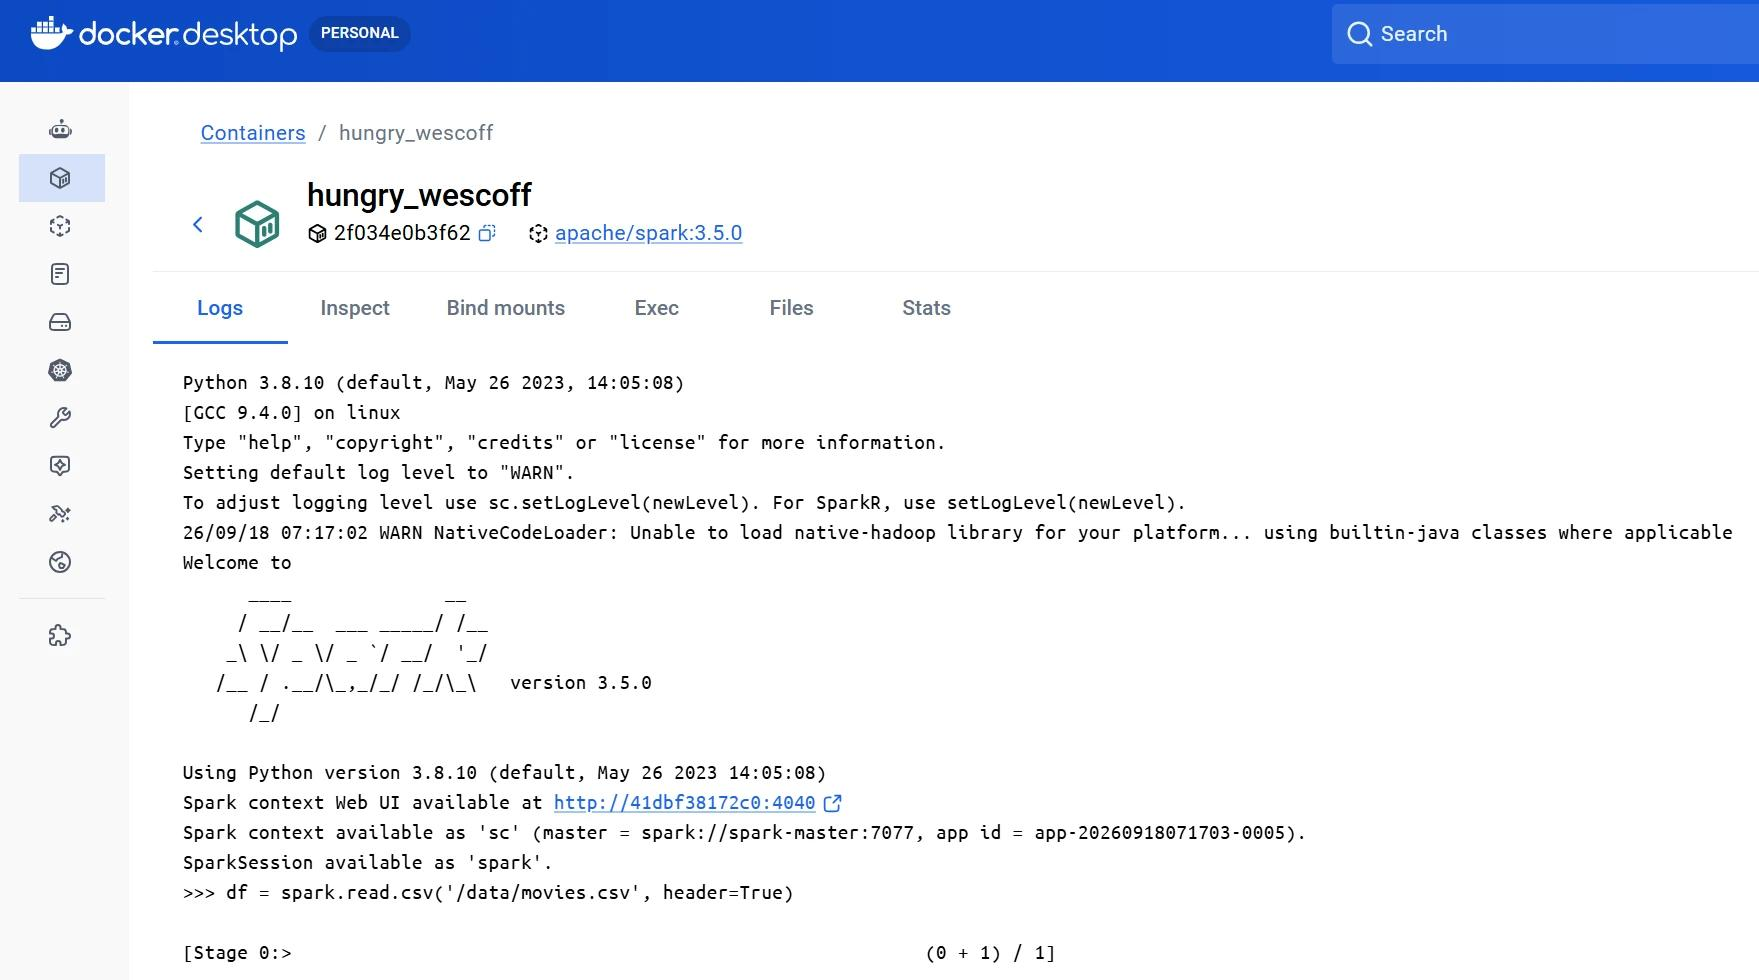

In [ ]:
img_path = '/content/drive/MyDrive/запуск_apache_spark.jpg'
img = Image.open(img_path)
display(img)

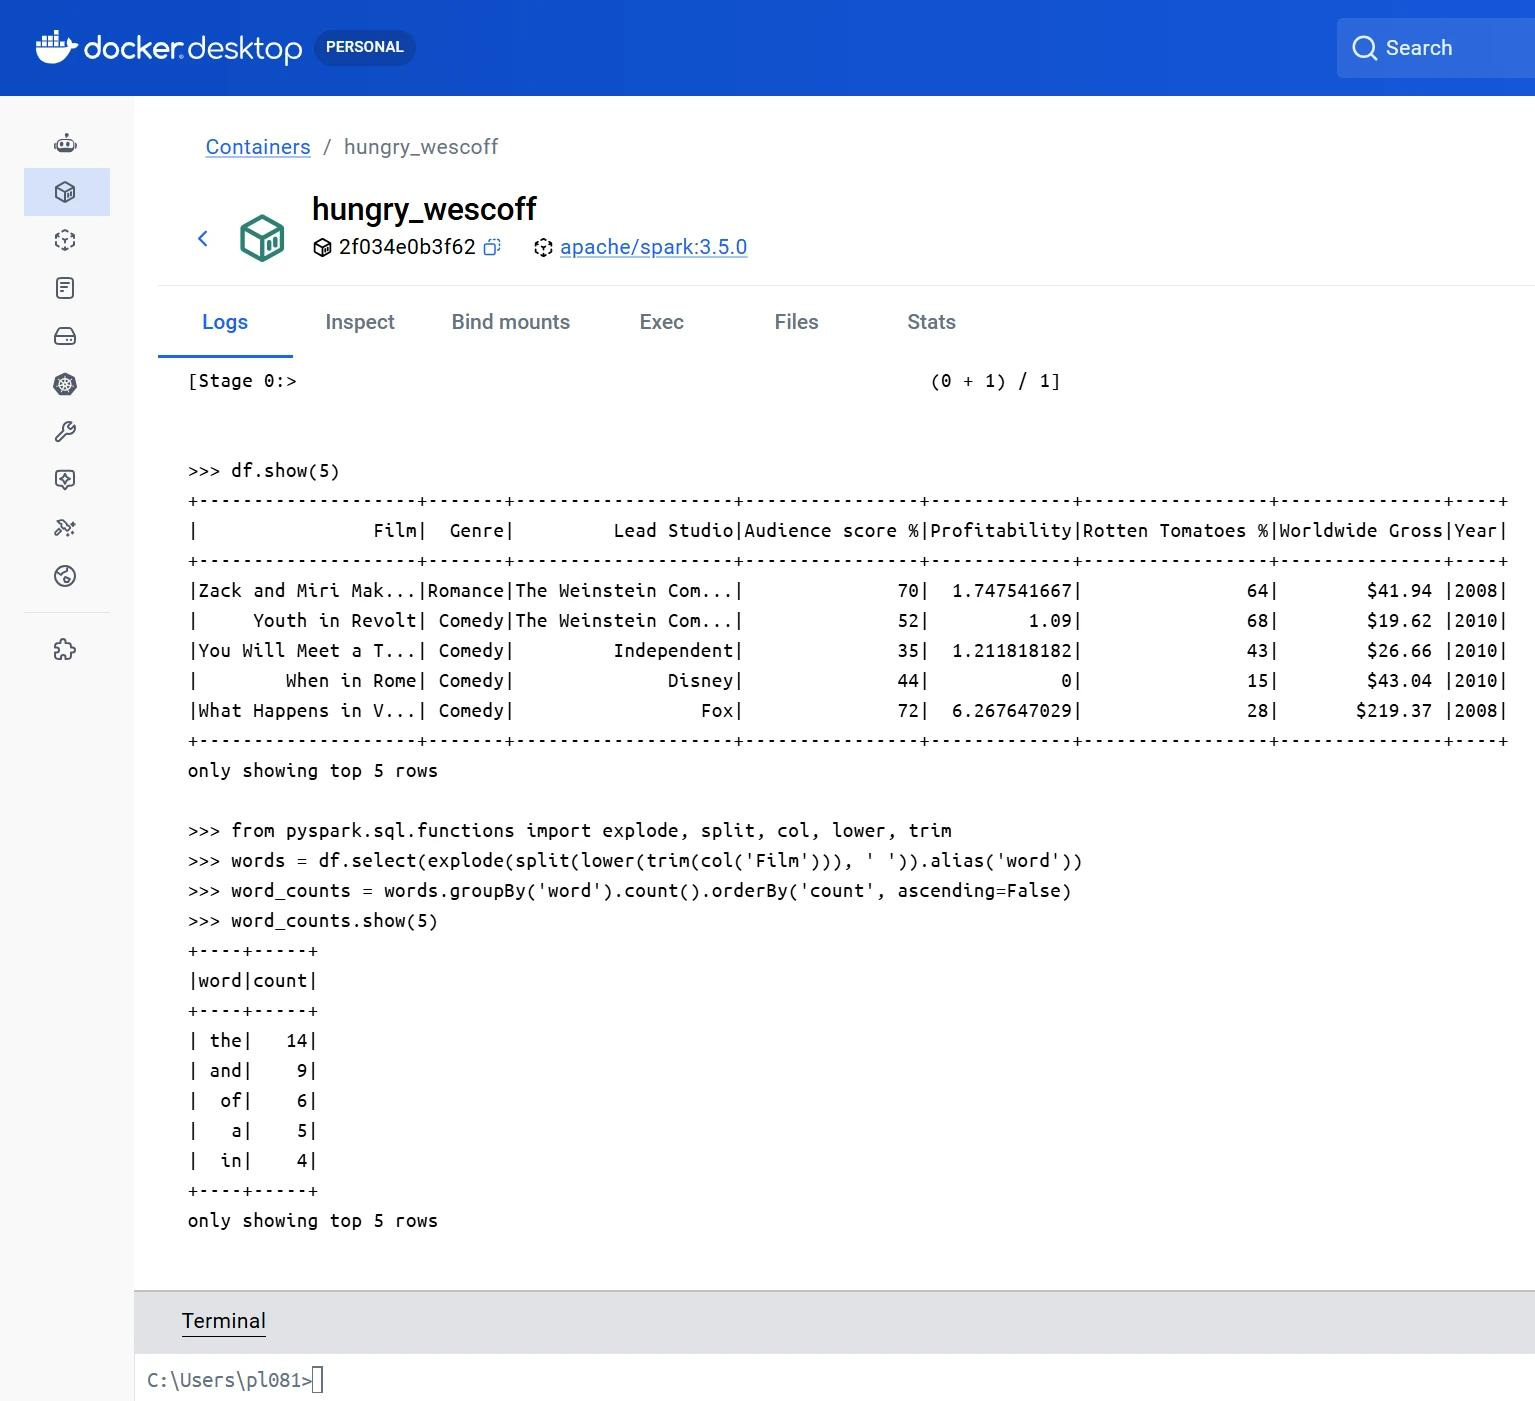

In [ ]:
img_path = '/content/drive/MyDrive/результат_дз_movies.jpg'
img = Image.open(img_path)
display(img)

# docker run -it --rm --network container:spark-master apache/spark:3.5.0 /opt/spark/bin/pyspark --master spark://spark-master:7077
# lower() — в нижний регистр.
# trim() — удаляем крайние пробелы.
# split(..., ' ') — разделяем название на слова по пробелам.
# explode() — список в строки.
# groupBy('word').count() — подсчитаем повторения.

# >>> from pyspark.sql.functions import explode, split, col, lower, trim
# >>> words = df.select(explode(split(lower(trim(col('Film'))), ' ')).alias('word'))
# >>> word_counts = words.groupBy('word').count().orderBy('count', ascending=False)
# >>> word_counts.show(5)

In [ ]:
#импортируем пандас
#выводим таблицу, определяем столбец, с которым работать (Film)
import pandas as pd
film = pd.read_csv('/content/drive/MyDrive/movies.csv', sep = ',', encoding='utf-8')
film.head()

,Film,Genre,Lead Studio,Audience score %,Profitability,Rotten Tomatoes %,Worldwide Gross,Year
0,Zack and Miri Make a Porno,Romance,The Weinstein Company,70,1.747542,64,$41.94,2008
1,Youth in Revolt,Comedy,The Weinstein Company,52,1.090000,68,$19.62,2010
2,You Will Meet a Tall Dark Stranger,Comedy,Independent,35,1.211818,43,$26.66,2010
3,When in Rome,Comedy,Disney,44,0.000000,15,$43.04,2010
4,What Happens in Vegas,Comedy,Fox,72,6.267647,28,$219.37,2008


In [ ]:
#выводим только нужный столбец
film = pd.read_csv('/content/drive/MyDrive/movies.csv', sep = ',', encoding='utf-8', usecols = ['Film'])
film.head()

,Film
0,Zack and Miri Make a Porno
1,Youth in Revolt
2,You Will Meet a Tall Dark Stranger
3,When in Rome
4,What Happens in Vegas


In [ ]:
#импортируем модуль стринг для отчистки текста от пунктуации
import string

film['Film'] = film['Film'].str.translate(str.maketrans(' ', ' ', string.punctuation))
film.head()

,Film
0,Zack and Miri Make a Porno
1,Youth in Revolt
2,You Will Meet a Tall Dark Stranger
3,When in Rome
4,What Happens in Vegas


In [ ]:
#приводим текст в нижний регистр
film['Film'] = film['Film'].str.lower()
film.head()

,Film
0,zack and miri make a porno
1,youth in revolt
2,you will meet a tall dark stranger
3,when in rome
4,what happens in vegas


In [ ]:
#разбиваем на слова
film['Film'] = film['Film'].str.split(' ')
film = film.explode('Film')
film.head()

,Film
0,zack
0,and
0,miri
0,make
0,a


In [ ]:
#производим группировку и
#подсчет вхождений в каждую группу,
#сортируем по убыванию и
#выводит первую строку с максимальным результатом, встретлось чаще всего слово the
film = film.groupby('Film').size().sort_values(ascending=False)
film.head(1)

,0
Film,
the,14
